In [1]:
import os
import PIL.Image as Image
import matplotlib.pyplot as plt
import numpy as np
import cv2

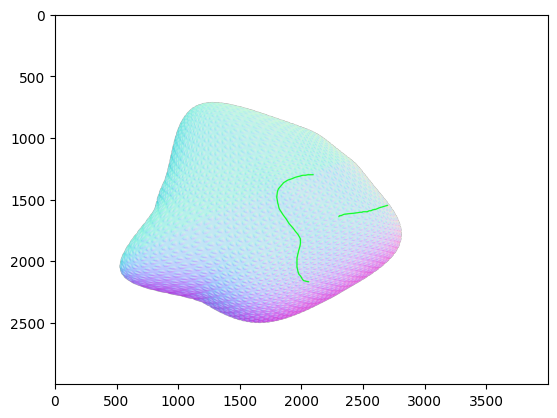

In [2]:
folder_path = "./images/patatoide/"
folder_path_out = "./images/patatoide_textures/"

image_test = Image.open(folder_path + "cam_00_rot_-20_led_19.png").convert('RGBA')
image_test = np.array(image_test)
plt.imshow(image_test)
plt.show()

In [3]:
def change_R(img, R):

    R = np.asarray(R, dtype=np.float32)

    img_f = img[:, :, :3].astype(np.float32)

    # masque avec alpha
    alpha = img[:, :, 3]
    mask = alpha > 0

    # reshape pour cv2.transform
    h, w, _ = img.shape
    reshaped = img_f.reshape(-1, 1, 3)

    transformed = cv2.transform(reshaped, R)
    transformed = transformed.reshape(h, w, 3)

    img_out = img_f.copy()
    img_out[mask] = np.clip(transformed[mask], 0, 255)

    # remettre le canal alpha
    img_out = np.dstack((img_out, alpha))

    return img_out.astype(np.uint8)

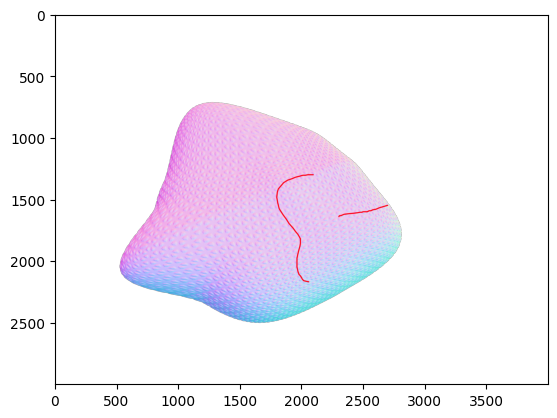

In [4]:
# Matrice de rotation de R360 degrees
R = [[0, 1, 0],
     [1, 0, 0],
     [0, 0, 1]]

image_test_R = change_R(image_test, R)

plt.imshow(image_test_R)
plt.show()

In [5]:
# trouver le min et le max non nul selon x et y
def crop_image_reshape(image, size=256):
    mask = image[:, :, 3] > 0  # utiliser le canal alpha comme masque
    coords = np.argwhere(mask)

    y0, x0 = coords.min(axis=0)
    y1, x1 = coords.max(axis=0) + 1  # ajouter 1 pour inclure le pixel max
    cropped = image[y0:y1, x0:x1]

    cropped = cv2.resize(cropped, (size, size), interpolation=cv2.INTER_AREA)

    return cropped

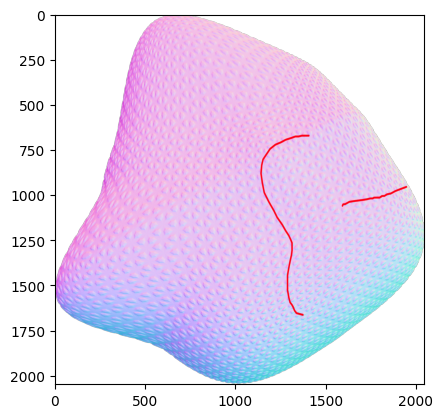

In [6]:
image_test_cropped = crop_image_reshape(image_test_R, 2048)
plt.imshow(image_test_cropped)
plt.show()

In [14]:

# Reset folder
if not os.path.exists(folder_path_out):
    os.makedirs(folder_path_out)

for i, img_name in enumerate(os.listdir(folder_path)):
    img = Image.open(os.path.join(folder_path, img_name)).convert('RGBA')
    img = np.array(img)
    img = change_R(img, R)
    img = crop_image_reshape(img, 2048)
    img_pil = Image.fromarray(img)
    img_name = os.path.splitext(img_name)[0]
    img_pil.save(os.path.join(folder_path_out, f"{img_name}_{i:03d}.png"))
    